# Actividad 3: Pipeline dual (CLAHE + CECED)

Este notebook implementa, de forma coherente con `Avance2_Equipo21_FeatureEngineering.ipynb`, un flujo para el dataset dual exportado:

- Carga de datos con `DDR2019DualFiltersDataset`.
- Normalización para la rama **CLAHE** (RGB + luminancia para brillo/contraste).
- Preprocesamiento mínimo para **CECED** (tensor en rango `[0,1]`).
- Augmentación geométrica síncrona para ambas ramas (flip y dos rotaciones distintas).
- Balanceo por clases: augmentation de minoritarias + downsampling de mayoritarias.
- Cálculo de vector de pesos de clase para entrenamiento.
- Resumen final en un solo bloque.

Reglas aplicadas:
- Identificadores de código en inglés.
- Texto Markdown y comentarios en español.
- Sin emojis.


## 1) Setup del proyecto y dependencias

Se detecta la raíz del proyecto usando `pyproject.toml`, se configuran semillas para reproducibilidad y se validan rutas del dataset dual preprocesado.


In [1]:
from __future__ import annotations

import os
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import Inception_V3_Weights, VGG16_Weights
from torchvision.transforms import functional as TF
from torchvision.transforms.functional import InterpolationMode

from sam_ml.datasets import DDR2019DualFiltersDataset

# Resolver la raíz del proyecto de forma robusta.
_path = Path.cwd()
while _path != _path.parent and not (_path / "pyproject.toml").exists():
    _path = _path.parent
PROJECT_ROOT = _path if (_path / "pyproject.toml").exists() else Path.cwd()
os.chdir(PROJECT_ROOT)

# Fijar semillas para reproducibilidad.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DATA_DIR = PROJECT_ROOT / "data" / "processed" / "ddr2019_dualfilters"
LABELS_CSV = DATA_DIR / "labels_dual.csv"

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"labels_dual.csv existe: {LABELS_CSV.exists()}")


PROJECT_ROOT: /Users/anaya/Develop/Robomous/sam-ai
DATA_DIR: /Users/anaya/Develop/Robomous/sam-ai/data/processed/ddr2019_dualfilters
labels_dual.csv existe: True


In [2]:
# Cargar dataset base dual y validar contrato de salida.
base_dataset_train = DDR2019DualFiltersDataset(
    data_dir=DATA_DIR,
    split="train",
    train_ratio=0.8,
    val_ratio=0.2,
    transform=transforms.ToTensor(),
    random_state=SEED,
)

base_dataset_all = DDR2019DualFiltersDataset(
    data_dir=DATA_DIR,
    split="all",
    transform=transforms.ToTensor(),
    random_state=SEED,
)

(clahe_sample, ceced_sample), label_sample = base_dataset_train[0]

print(f"Muestras train: {len(base_dataset_train)}")
print(f"Muestras all: {len(base_dataset_all)}")
print(f"Shape CLAHE: {tuple(clahe_sample.shape)}")
print(f"Shape CECED: {tuple(ceced_sample.shape)}")
print(f"Label de ejemplo: {label_sample}")


Muestras train: 10015
Muestras all: 12522
Shape CLAHE: (3, 299, 299)
Shape CECED: (3, 224, 224)
Label de ejemplo: 0


## 2) Configuración de preprocesamiento esperada por backbone

Se utiliza la normalización estándar esperada por los backbones preentrenados:

- Rama **CLAHE** -> **Inception V3** (`299 x 299`).
- Rama **CECED** -> **VGG-16** (`224 x 224`).

No se calculan estadísticas manuales del dataset para evitar desalineaciones con los pesos preentrenados.


In [3]:
# Definir pesos de referencia para cada rama.
inception_weights = Inception_V3_Weights.IMAGENET1K_V1
vgg16_weights = VGG16_Weights.IMAGENET1K_V1


def get_backbone_norm_stats(weights_enum) -> tuple[torch.Tensor, torch.Tensor]:
    """Obtener media y desviación estándar esperadas por un backbone torchvision."""
    preset = weights_enum.transforms()
    mean = torch.tensor(preset.mean, dtype=torch.float32)
    std = torch.tensor(preset.std, dtype=torch.float32)
    return mean, std


clahe_norm_mean, clahe_norm_std = get_backbone_norm_stats(inception_weights)
ceced_norm_mean, ceced_norm_std = get_backbone_norm_stats(vgg16_weights)

print("Normalización por backbone (sin cálculo manual de estadísticas):")
print("  CLAHE -> Inception V3")
print(f"    input_size esperado: {inception_weights.transforms().crop_size[0]} x {inception_weights.transforms().crop_size[0]}")
print(f"    mean: {clahe_norm_mean.tolist()}")
print(f"    std: {clahe_norm_std.tolist()}")
print("  CECED -> VGG-16")
print(f"    input_size esperado: {vgg16_weights.transforms().crop_size[0]} x {vgg16_weights.transforms().crop_size[0]}")
print(f"    mean: {ceced_norm_mean.tolist()}")
print(f"    std: {ceced_norm_std.tolist()}")


Normalización por backbone (sin cálculo manual de estadísticas):
  CLAHE -> Inception V3
    input_size esperado: 299 x 299
    mean: [0.48500001430511475, 0.4560000002384186, 0.4059999883174896]
    std: [0.2290000021457672, 0.2240000069141388, 0.22499999403953552]
  CECED -> VGG-16
    input_size esperado: 224 x 224
    mean: [0.48500001430511475, 0.4560000002384186, 0.4059999883174896]
    std: [0.2290000021457672, 0.2240000069141388, 0.22499999403953552]


## 3) Transformaciones de normalización

Se aplican transformaciones compatibles con los backbones objetivo:

1. **CLAHE / Inception V3**: normalización con las estadísticas esperadas por `Inception_V3_Weights`.
2. **CECED / VGG-16**: normalización con las estadísticas esperadas por `VGG16_Weights`.

La augmentación geométrica síncrona y el downsampling se mantienen sin cambios.


In [4]:
def normalize_with_stats_torch(x: torch.Tensor, mean: torch.Tensor, std: torch.Tensor) -> torch.Tensor:
    """Normalizar tensor RGB con media/desviación esperadas por un backbone."""
    m = mean.view(3, 1, 1).to(x.device, x.dtype)
    s = std.view(3, 1, 1).to(x.device, x.dtype).clamp_min(1e-8)
    return (x - m) / s


def denormalize_with_stats_torch(x: torch.Tensor, mean: torch.Tensor, std: torch.Tensor) -> torch.Tensor:
    """Deshacer normalización RGB para visualización."""
    m = mean.view(3, 1, 1).to(x.device, x.dtype)
    s = std.view(3, 1, 1).to(x.device, x.dtype)
    return x * s + m


def preprocess_clahe_for_inception(x: torch.Tensor) -> torch.Tensor:
    """Preprocesar CLAHE según expectativa de Inception V3 (ImageNet mean/std)."""
    x = x.float().clamp(0.0, 1.0)
    return normalize_with_stats_torch(x, clahe_norm_mean, clahe_norm_std)


def preprocess_ceced_for_vgg(x: torch.Tensor) -> torch.Tensor:
    """Preprocesar CECED según expectativa de VGG-16 (ImageNet mean/std)."""
    x = x.float().clamp(0.0, 1.0)
    return normalize_with_stats_torch(x, ceced_norm_mean, ceced_norm_std)


## 4) Balanceo de clases (coherente con Avance2, adaptado)

Criterios:

- Minoriatarias: `count < mean_count * 0.5`.
- Augmentation minoritarias: `AUGMENTATION_MULTIPLIER = 5` (original + HFlip + VFlip + Rot1 + Rot2).
- Mayoritarias: downsampling con `MAJORITY_CAP = 3500` si `count > mean_count` y `count > MAJORITY_CAP`.


In [5]:
train_rows = base_dataset_train._rows.reset_index(drop=True).copy()

class_counts = train_rows["label"].value_counts().sort_index()
mean_count = class_counts.mean()
minority_threshold = mean_count * 0.5
minority_classes = set(class_counts[class_counts < minority_threshold].index.tolist())

AUGMENTATION_MULTIPLIER = 5
MAJORITY_CAP = 3500

augmentation_targets: dict[int, dict[str, float]] = {}
for label, count in class_counts.items():
    is_minority = int(label) in minority_classes
    target_count = int(count) * AUGMENTATION_MULTIPLIER if is_minority else int(count)
    augmentation_targets[int(label)] = {
        "current_count": int(count),
        "target_count": int(target_count),
        "multiplier": AUGMENTATION_MULTIPLIER if is_minority else 1,
        "is_minority": is_minority,
    }

downsampling_ratios: dict[int, dict[str, float]] = {}
for label, count in class_counts.items():
    is_majority = float(count) > float(mean_count)
    if is_majority and int(count) > MAJORITY_CAP:
        new_count = MAJORITY_CAP
        reduction_pct = (1.0 - (new_count / int(count))) * 100.0
    else:
        new_count = int(count)
        reduction_pct = 0.0
    downsampling_ratios[int(label)] = {
        "current_count": int(count),
        "new_count": int(new_count),
        "reduction_pct": float(reduction_pct),
        "is_downsampled": bool(is_majority and int(count) > MAJORITY_CAP),
    }

final_counts: dict[int, int] = {}
for label in sorted(class_counts.index.tolist()):
    if int(label) in minority_classes:
        final_counts[int(label)] = int(augmentation_targets[int(label)]["target_count"])
    else:
        final_counts[int(label)] = int(downsampling_ratios[int(label)]["new_count"])

original_imbalance_ratio = float(class_counts.max() / class_counts.min())
final_counts_series = pd.Series(final_counts).sort_index()
final_imbalance_ratio = float(final_counts_series.max() / final_counts_series.min())

print("Resumen de balanceo (sobre split de entrenamiento):")
print(f"  class_counts: {class_counts.to_dict()}")
print(f"  mean_count: {mean_count:.2f}")
print(f"  minority_threshold (50% mean): {minority_threshold:.2f}")
print(f"  minority_classes: {sorted(list(minority_classes))}")
print(f"  AUGMENTATION_MULTIPLIER: {AUGMENTATION_MULTIPLIER}")
print(f"  MAJORITY_CAP: {MAJORITY_CAP}")
print(f"  ratio original: {original_imbalance_ratio:.2f}:1")
print(f"  ratio final: {final_imbalance_ratio:.2f}:1")


Resumen de balanceo (sobre split de entrenamiento):
  class_counts: {0: 5012, 1: 504, 2: 3581, 3: 188, 4: 730}
  mean_count: 2003.00
  minority_threshold (50% mean): 1001.50
  minority_classes: [1, 3, 4]
  AUGMENTATION_MULTIPLIER: 5
  MAJORITY_CAP: 3500
  ratio original: 26.66:1
  ratio final: 3.88:1


## 5) Wrapper dual con augmentación síncrona y downsampling

Este dataset envuelve el loader base y aplica:

- Muestreo balanceado por clase según reglas definidas.
- Augmentación geométrica síncrona para CLAHE y CECED.
- Normalización específica por rama basada en backbones (Inception V3 para CLAHE, VGG-16 para CECED).


In [6]:
def _sample_indices_per_class(
    rows: pd.DataFrame,
    majority_cap: int,
    seed: int,
) -> list[int]:
    """Aplicar downsampling por clase para mayoritarias y mantener el resto."""
    rng = np.random.default_rng(seed)
    selected: list[int] = []

    counts = rows["label"].value_counts().sort_index()
    mean_count_local = counts.mean()

    for label in sorted(counts.index.tolist()):
        cls_rows = rows[rows["label"] == label]
        cls_indices = cls_rows.index.to_numpy()
        is_majority = counts[label] > mean_count_local

        if is_majority and len(cls_indices) > majority_cap:
            chosen = rng.choice(cls_indices, size=majority_cap, replace=False)
            selected.extend(chosen.tolist())
        else:
            selected.extend(cls_indices.tolist())

    return selected


def _build_augmented_sample_list(
    rows: pd.DataFrame,
    selected_indices: list[int],
    minority_set: set[int],
) -> list[tuple[int, int]]:
    """Construir lista (base_index, aug_id) según clase minoritaria/no minoritaria."""
    samples: list[tuple[int, int]] = []
    for idx in selected_indices:
        label = int(rows.loc[idx, "label"])
        if label in minority_set:
            # 0 = original, 1 = hflip, 2 = vflip, 3 = rot1, 4 = rot2
            for aug_id in (0, 1, 2, 3, 4):
                samples.append((int(idx), int(aug_id)))
        else:
            samples.append((int(idx), 0))
    return samples


def _draw_rotation_angles(rng: np.random.Generator) -> tuple[float, float]:
    """Generar dos ángulos distintos con magnitud en [10,15]."""
    def _one_angle() -> float:
        mag = float(rng.uniform(10.0, 15.0))
        sign = -1.0 if rng.random() < 0.5 else 1.0
        return sign * mag

    angle1 = _one_angle()
    angle2 = _one_angle()
    while abs(angle2 - angle1) < 1e-6:
        angle2 = _one_angle()
    return angle1, angle2


class BalancedAugmentedDualDataset(Dataset):
    """Dataset dual balanceado con augmentación geométrica síncrona."""

    def __init__(
        self,
        base_dataset: DDR2019DualFiltersDataset,
        clahe_transform,
        minority_set: set[int],
        majority_cap: int = 3500,
        seed: int = 42,
    ) -> None:
        self.base_dataset = base_dataset
        self.clahe_transform = clahe_transform
        self.minority_set = set(int(x) for x in minority_set)
        self.majority_cap = int(majority_cap)
        self.seed = int(seed)

        rows = base_dataset._rows.reset_index(drop=True).copy()
        self.rows = rows

        selected = _sample_indices_per_class(rows, self.majority_cap, self.seed)
        self.samples = _build_augmented_sample_list(rows, selected, self.minority_set)

    def __len__(self) -> int:
        return len(self.samples)

    def _apply_sync_geometry(
        self,
        clahe: torch.Tensor,
        ceced: torch.Tensor,
        aug_id: int,
        idx: int,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """Aplicar misma geometría en ambas ramas."""
        if aug_id == 0:
            return clahe, ceced
        if aug_id == 1:
            return TF.hflip(clahe), TF.hflip(ceced)
        if aug_id == 2:
            return TF.vflip(clahe), TF.vflip(ceced)

        rng = np.random.default_rng(self.seed + idx)
        angle1, angle2 = _draw_rotation_angles(rng)
        angle = angle1 if aug_id == 3 else angle2

        clahe_out = TF.rotate(
            clahe,
            angle=angle,
            interpolation=InterpolationMode.BILINEAR,
            fill=0.0,
        )
        ceced_out = TF.rotate(
            ceced,
            angle=angle,
            interpolation=InterpolationMode.NEAREST,
            fill=0.0,
        )
        return clahe_out, ceced_out

    def __getitem__(self, item_idx: int) -> tuple[tuple[torch.Tensor, torch.Tensor], int]:
        base_index, aug_id = self.samples[item_idx]
        (clahe, ceced), label = self.base_dataset[int(base_index)]

        clahe_aug, ceced_aug = self._apply_sync_geometry(
            clahe.float(),
            ceced.float(),
            int(aug_id),
            int(base_index),
        )

        clahe_processed = self.clahe_transform(clahe_aug)
        ceced_processed = preprocess_ceced_for_vgg(ceced_aug)

        return (clahe_processed, ceced_processed), int(label)


balanced_dataset = BalancedAugmentedDualDataset(
    base_dataset=base_dataset_train,
    clahe_transform=preprocess_clahe_for_inception,
    minority_set=minority_classes,
    majority_cap=MAJORITY_CAP,
    seed=SEED,
)

print(f"Tamaño dataset balanceado/augmentado: {len(balanced_dataset)}")


Tamaño dataset balanceado/augmentado: 14110


## 6) Verificación, pesos de clase y resumen final

En esta celda se ejecuta el resumen completo:

- Validación de batch del `DataLoader`.
- Cálculo de `class_weight_vector` con la fórmula de frecuencia inversa.
- Comparación de distribución original vs final.
- Visualización de muestras CLAHE/CECED tras el pipeline.


In [7]:
# Construir DataLoader del dataset balanceado.
batch_size = 8
balanced_loader = DataLoader(
    balanced_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
)

(clahe_batch, ceced_batch), labels_batch = next(iter(balanced_loader))

# Calcular vector de pesos de clase sobre distribución final.
num_samples_final = int(final_counts_series.sum())
num_classes = int(len(final_counts_series))
class_weight_vector = torch.tensor(
    [num_samples_final / (num_classes * int(final_counts_series.loc[c])) for c in sorted(final_counts_series.index)],
    dtype=torch.float32,
)

# Desnormalizar ramas solo para visualización.
clahe_batch_for_display = denormalize_with_stats_torch(
    clahe_batch.detach().cpu(),
    clahe_norm_mean.detach().cpu(),
    clahe_norm_std.detach().cpu(),
).clamp(0.0, 1.0)

ceced_batch_for_display = denormalize_with_stats_torch(
    ceced_batch.detach().cpu(),
    ceced_norm_mean.detach().cpu(),
    ceced_norm_std.detach().cpu(),
).clamp(0.0, 1.0)


=== Resumen de pipeline dual ===
DATA_DIR: /Users/anaya/Develop/Robomous/sam-ai/data/processed/ddr2019_dualfilters
Split train base: 10015
Split train balanceado/augmentado: 14110
clahe_batch shape: (8, 3, 299, 299)
ceced_batch shape: (8, 3, 224, 224)
labels_batch shape: (8,)
Distribución original (train): {0: 5012, 1: 504, 2: 3581, 3: 188, 4: 730}
Distribución final objetivo: {0: 3500, 1: 2520, 2: 3500, 3: 940, 4: 3650}
Ratio original: 26.66:1
Ratio final: 3.88:1
class_weight_vector: [0.8062857389450073, 1.11984121799469, 0.8062857389450073, 3.0021276473999023, 0.7731506824493408]


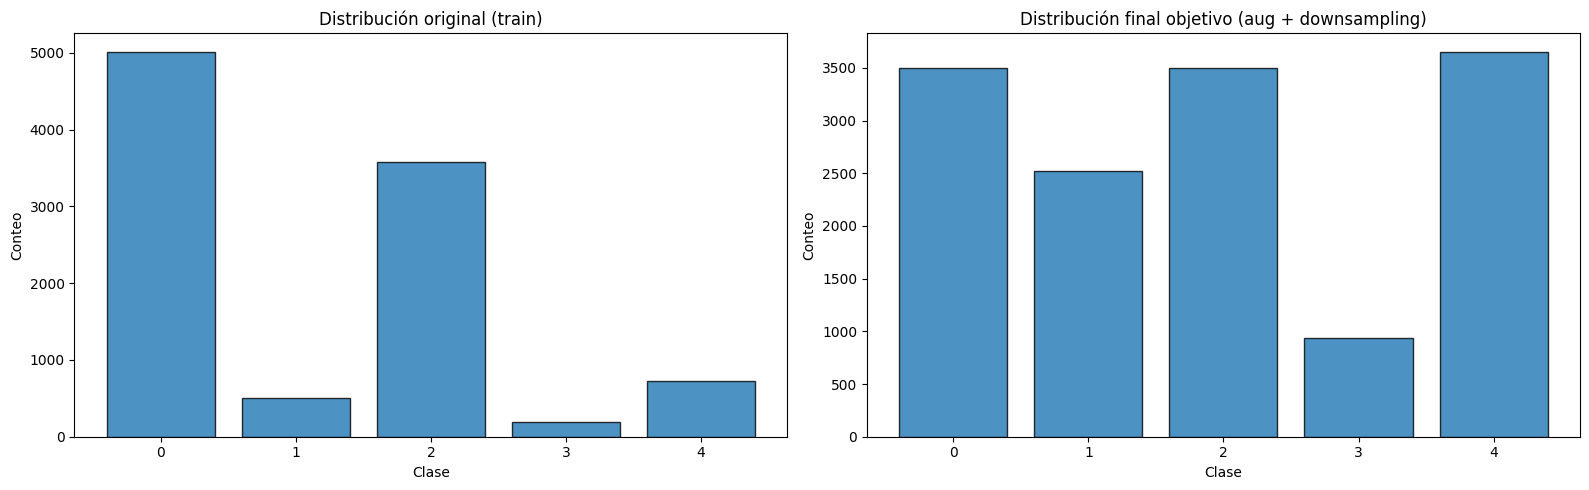

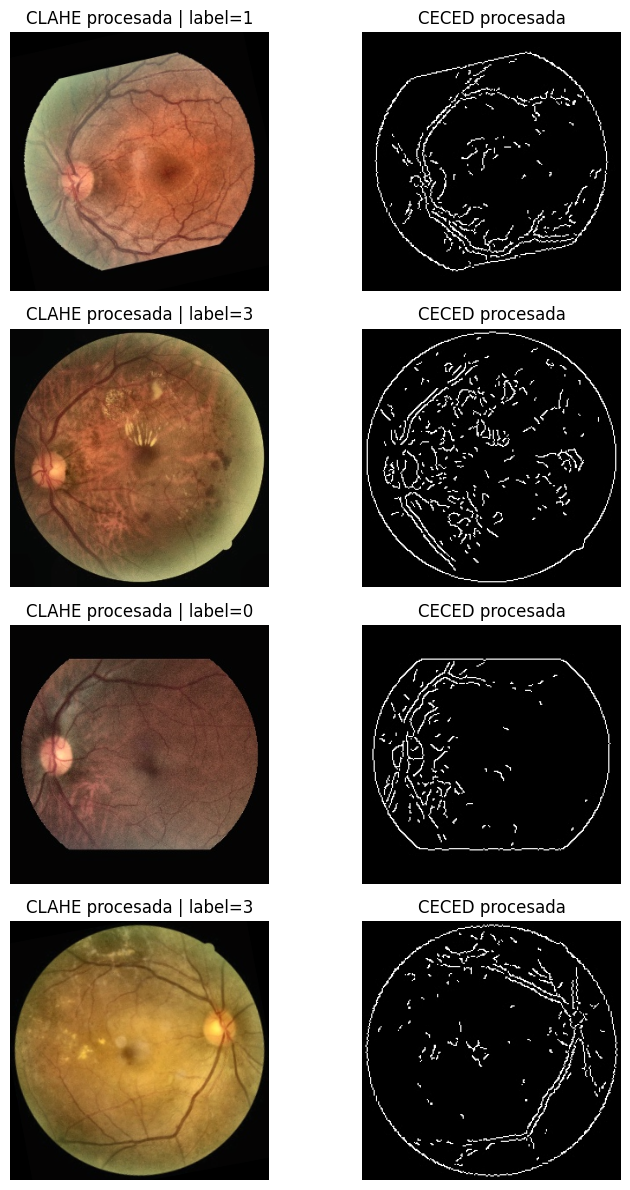

In [8]:
print("=== Resumen de pipeline dual ===")
print(f"DATA_DIR: {DATA_DIR}")
print(f"Split train base: {len(base_dataset_train)}")
print(f"Split train balanceado/augmentado: {len(balanced_dataset)}")
print(f"clahe_batch shape: {tuple(clahe_batch.shape)}")
print(f"ceced_batch shape: {tuple(ceced_batch.shape)}")
print(f"labels_batch shape: {tuple(labels_batch.shape)}")
print(f"Distribución original (train): {class_counts.to_dict()}")
print(f"Distribución final objetivo: {final_counts_series.to_dict()}")
print(f"Ratio original: {original_imbalance_ratio:.2f}:1")
print(f"Ratio final: {final_imbalance_ratio:.2f}:1")
print(f"class_weight_vector: {class_weight_vector.tolist()}")

# Graficar distribución original vs final.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

classes_sorted = sorted(class_counts.index.tolist())
x = np.arange(len(classes_sorted))
orig_values = [int(class_counts.loc[c]) for c in classes_sorted]
final_values = [int(final_counts_series.loc[c]) for c in classes_sorted]

axes[0].bar(x, orig_values, edgecolor="black", alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(classes_sorted)
axes[0].set_title("Distribución original (train)")
axes[0].set_xlabel("Clase")
axes[0].set_ylabel("Conteo")

axes[1].bar(x, final_values, edgecolor="black", alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(classes_sorted)
axes[1].set_title("Distribución final objetivo (aug + downsampling)")
axes[1].set_xlabel("Clase")
axes[1].set_ylabel("Conteo")

plt.tight_layout()
plt.show()

# Mostrar muestras del batch: CLAHE y CECED lado a lado.
# Ambas ramas se desnormalizan solo para inspección visual.
n_show = min(4, clahe_batch.shape[0])
fig, axes = plt.subplots(n_show, 2, figsize=(8, 3 * n_show))
if n_show == 1:
    axes = np.array([axes])

for i in range(n_show):
    clahe_vis = clahe_batch_for_display[i]
    ceced_vis = ceced_batch_for_display[i]

    axes[i, 0].imshow(np.transpose(clahe_vis.numpy(), (1, 2, 0)))
    axes[i, 0].set_title(f"CLAHE procesada | label={int(labels_batch[i])}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(np.transpose(ceced_vis.numpy(), (1, 2, 0)))
    axes[i, 1].set_title("CECED procesada")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()